In [3]:
from Graph import Graph
from filter import apply_disparity_filter, get_backbone

# 1. Create Graph
random_test = Graph.random(n=10000, k=10, seed=42)
print("--- Original ---")
random_test.describe_graph()  


# 2. Apply Filter (In-place modification of random_test.G)
apply_disparity_filter(random_test.G)

# 3. Extract Backbone
alpha_val = 0.2
backbone_nx = get_backbone(random_test.G, alpha_val)

# 4. Wrap Backbone in Graph Class to analyze it
random_backbone = Graph(backbone_nx)

print(f"\n--- Backbone (alpha={alpha_val}) ---")
random_backbone.describe_graph() 

--- Original ---

Graph: 10000 nodes, 49964 edges


--- Backbone (alpha=0.2) ---

Graph: 9226 nodes, 10873 edges



In [4]:
scale_free = Graph.scale_free(n=10000, seed=42)
scale_free.describe_graph()

# 2. Apply Filter 
apply_disparity_filter(scale_free.G)
alpha_val = 0.20
backbone_nx = get_backbone(scale_free.G, alpha_val)

# 4. Wrap Backbone in Graph Class 
scale_free_backbone = Graph(backbone_nx)

print(f"\n--- Backbone (alpha={alpha_val}) ---")
scale_free_backbone.describe_graph() 



Graph: 10000 nodes, 19996 edges


--- Backbone (alpha=0.2) ---

Graph: 5819 nodes, 4404 edges



In [ ]:
scale_free_backbone.save_graph("graphs/scale_free_backbone.gexf") #no funciona en gephi


In [8]:
random_test.__sizeof__()

24

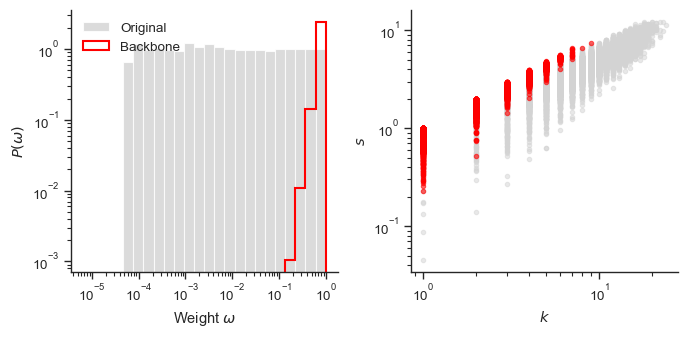

In [21]:
from PlotUtils import plot_backbone_statistics
    
plot_backbone_statistics(random_test.G,random_backbone.G, directed=False)  

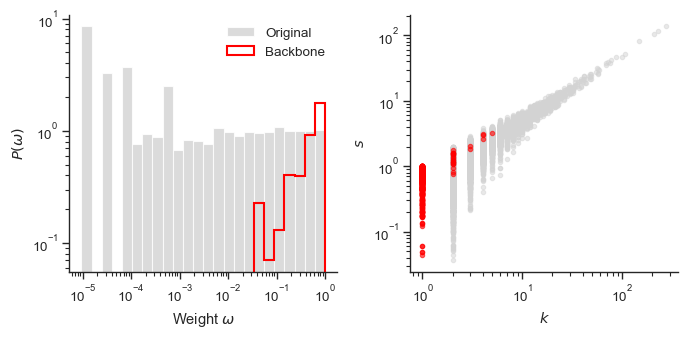

In [16]:
plot_backbone_statistics(scale_free.G,scale_free_backbone.G, directed=False)

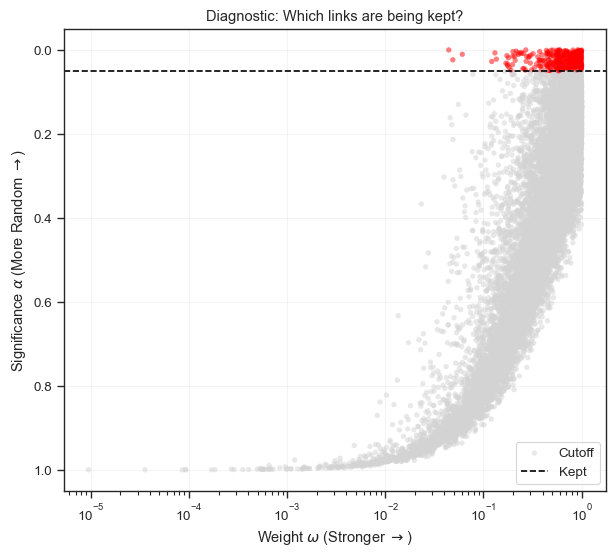

In [22]:
from PlotUtils import plot_alpha_vs_weight

plot_alpha_vs_weight(scale_free.G, alpha_cutoff=0.05)